# Zadanie: PCA – Zbiór Wine

**Cel:** Zastosowanie PCA do zbioru Wine w celu redukcji wymiarowości i analizy struktury danych.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ustawienia wykresów
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 12

## Część 1: Przygotowanie danych

### 1.1 i 1.2 Załadowanie i opis danych

In [2]:
# 1.1 Załadowanie danych
wine = load_wine()
X = wine.data
y = wine.target
nazwy_cech = wine.feature_names
nazwy_klas = list(wine.target_names)

# 1.2 Wyświetlenie podstawowych informacji
print(f"Wymiary danych: {X.shape[0]} próbek x {X.shape[1]} cech")
print(f"Cechy: {list(nazwy_cech)}")
print(f"Klasy: {nazwy_klas}")
print("\nRozkład klas:")
for i, kl in enumerate(nazwy_klas):
    print(f"  Klasa {i} ({kl}): {(y==i).sum()} próbek")

Wymiary danych: 178 próbek x 13 cech
Cechy: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Klasy: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Rozkład klas:
  Klasa 0 (class_0): 59 próbek
  Klasa 1 (class_1): 71 próbek
  Klasa 2 (class_2): 48 próbek


### 1.3 Standaryzacja danych

**Dlaczego standaryzacja jest konieczna przed PCA?**

PCA jest wrażliwe na skalę cech. Cechy o większej wariancji dominują w analizie. W zbiorze Wine cecha `proline` ma wartości rzędu 400–1600, podczas gdy inne cechy mają zakresy 0–5. Bez standaryzacji PCA byłoby zdominowane przez `proline`. Standaryzacja (z-score, mean=0, std=1) zapewnia równy wpływ wszystkich 13 cech.

In [3]:
# 1.3 Standaryzacja
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("=" * 60)
print("STANDARYZACJA (mean=0, std=1)")
print("=" * 60)
print(f"Przed standaryzacją - odchylenia std:")
print(f"  {X.std(axis=0).round(3)}")
print(f"Po standaryzacji   - odchylenia std:")
print(f"  {X_std.std(axis=0).round(3)}")
print("\nWyjaśnienie: cecha 'proline' (zakres 400-1600) byłaby zdominowana")
print("bez standaryzacji. Standaryzacja wyrównuje wpływ wszystkich cech.")

STANDARYZACJA (mean=0, std=1)
Przed standaryzacją - odchylenia std:
  [8.10000e-01 1.11400e+00 2.74000e-01 3.33000e+00 1.42420e+01 6.24000e-01
 9.96000e-01 1.24000e-01 5.71000e-01 2.31200e+00 2.28000e-01 7.08000e-01
 3.14022e+02]
Po standaryzacji   - odchylenia std:
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Wyjaśnienie: cecha 'proline' (zakres 400-1600) byłaby zdominowana
bez standaryzacji. Standaryzacja wyrównuje wpływ wszystkich cech.


## Część 2: Wykonanie PCA

### 2.1 i 2.2 PCA – wartości własne i wariancja

In [4]:
# 2.1 i 2.2 Wykonanie PCA
pca = PCA()  # Wszystkie składowe
X_pca = pca.fit_transform(X_std)

print("=" * 60)
print("WYNIKI PCA")
print("=" * 60)

print("\nWartości własne (eigenvalues):")
for i, ev in enumerate(pca.explained_variance_):
    print(f"  PC{i+1}: {ev:.4f}")

print("\nWyjaśniona wariancja (%):")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.2f}%")

cumsum = np.cumsum(pca.explained_variance_ratio_)
print("\nSkumulowana wariancja:")
for i, cs in enumerate(cumsum):
    print(f"  PC1-PC{i+1}: {cs*100:.2f}%")

# 2.3
n_80 = np.argmax(cumsum >= 0.80) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\n=> Do >=80% wariancji potrzeba: {n_80} składowych")
print(f"=> Do >=95% wariancji potrzeba: {n_95} składowych")
print(f"=> PC1 + PC2 wyjaśniają: {cumsum[1]*100:.1f}% wariancji")

WYNIKI PCA

Wartości własne (eigenvalues):
  PC1: 4.7324
  PC2: 2.5111
  PC3: 1.4542
  PC4: 0.9242
  PC5: 0.8580
  PC6: 0.6453
  PC7: 0.5541
  PC8: 0.3505
  PC9: 0.2905
  PC10: 0.2523
  PC11: 0.2271
  PC12: 0.1697
  PC13: 0.1040

Wyjaśniona wariancja (%):
  PC1: 36.20%
  PC2: 19.21%
  PC3: 11.12%
  PC4: 7.07%
  PC5: 6.56%
  PC6: 4.94%
  PC7: 4.24%
  PC8: 2.68%
  PC9: 2.22%
  PC10: 1.93%
  PC11: 1.74%
  PC12: 1.30%
  PC13: 0.80%

Skumulowana wariancja:
  PC1-PC1: 36.20%
  PC1-PC2: 55.41%
  PC1-PC3: 66.53%
  PC1-PC4: 73.60%
  PC1-PC5: 80.16%
  PC1-PC6: 85.10%
  PC1-PC7: 89.34%
  PC1-PC8: 92.02%
  PC1-PC9: 94.24%
  PC1-PC10: 96.17%
  PC1-PC11: 97.91%
  PC1-PC12: 99.20%
  PC1-PC13: 100.00%

=> Do >=80% wariancji potrzeba: 5 składowych
=> Do >=95% wariancji potrzeba: 10 składowych
=> PC1 + PC2 wyjaśniają: 55.4% wariancji


## Część 3: Wizualizacja

### 3.1 Scree Plot | 3.2 Projekcja 2D | 3.3 Biplot

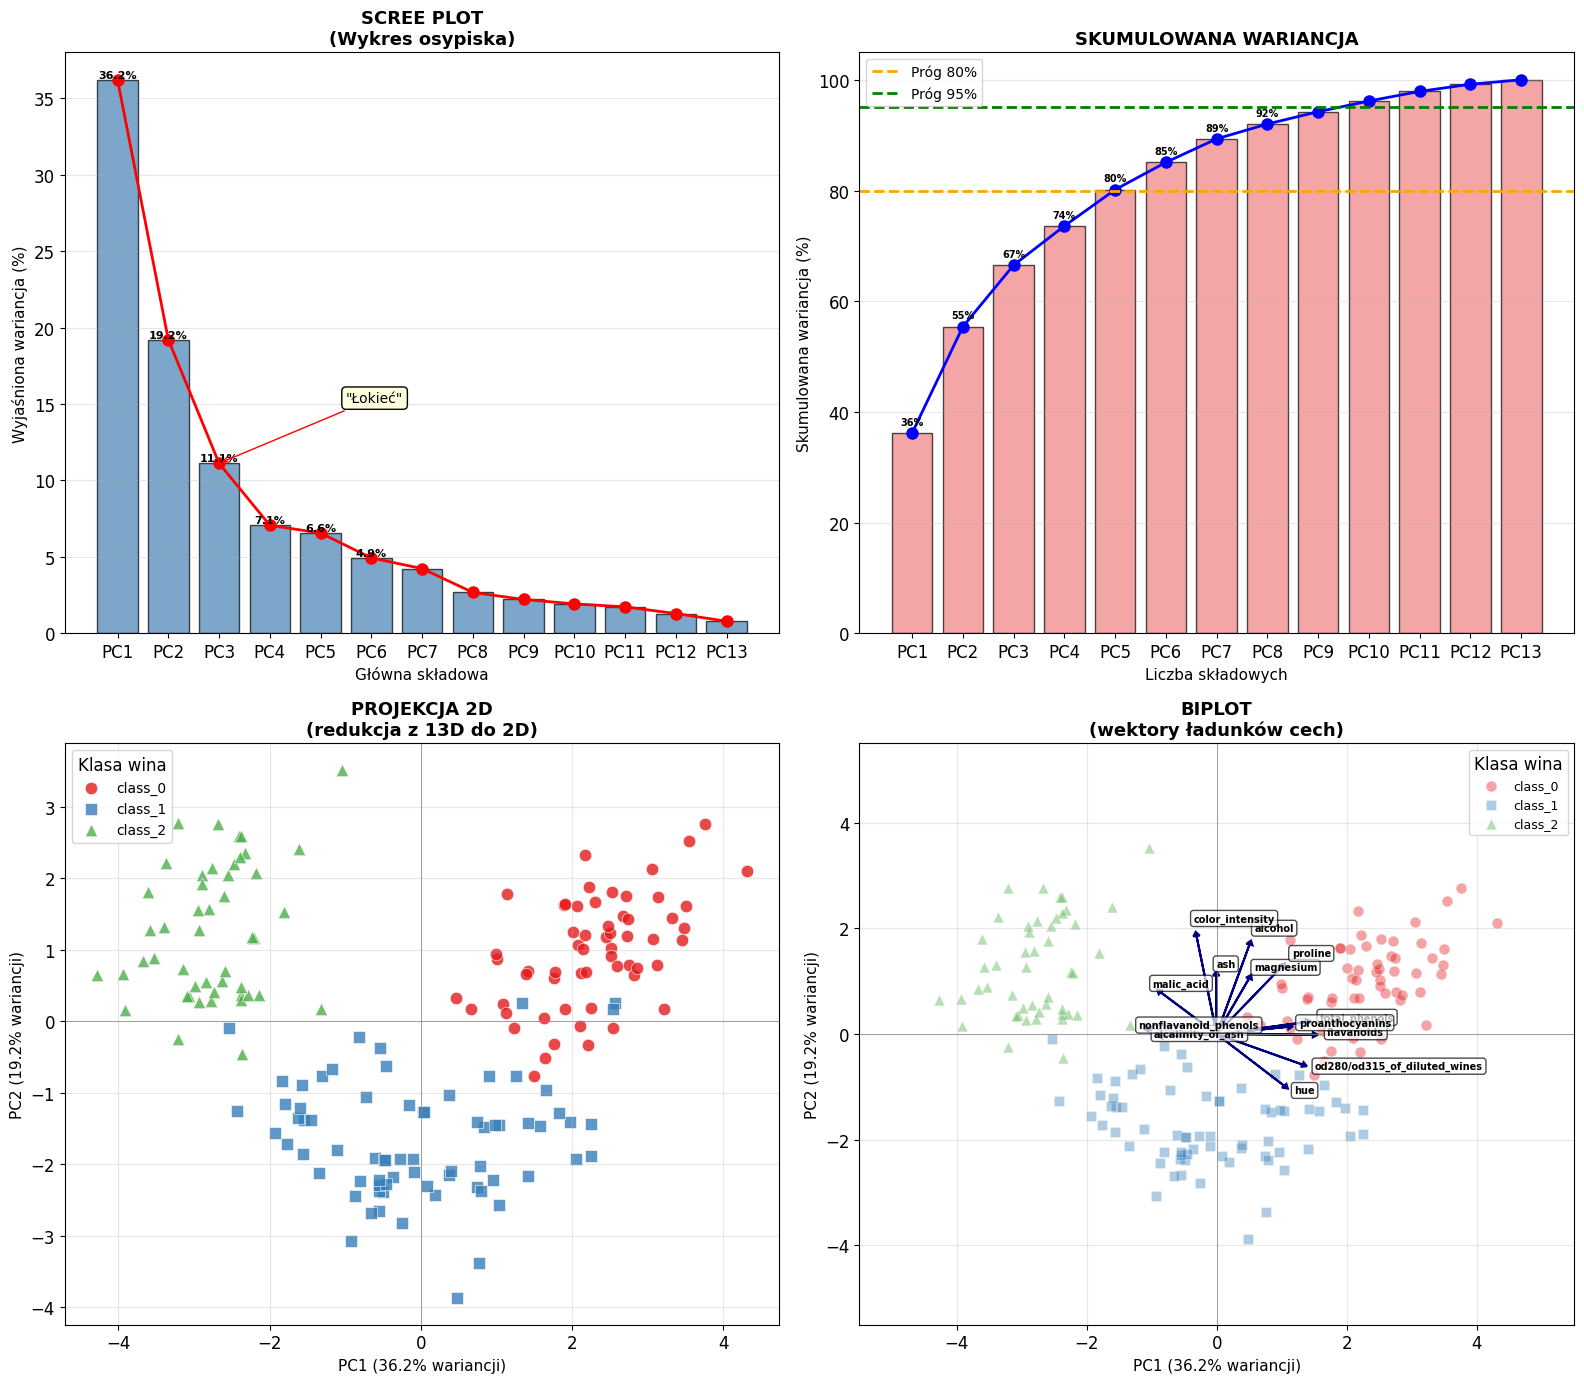

In [5]:
variance_pct = pca.explained_variance_ratio_ * 100
pc_labels = [f'PC{i+1}' for i in range(len(variance_pct))]
cumulative = np.cumsum(variance_pct)
colors = ['#e41a1c', '#377eb8', '#4daf4a']
markers_list = ['o', 's', '^']

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- 3.1 Scree Plot ---
ax1 = axes[0, 0]
bars = ax1.bar(pc_labels, variance_pct, color='steelblue', edgecolor='black', alpha=0.7)
ax1.plot(pc_labels, variance_pct, 'ro-', markersize=8, linewidth=2)
ax1.set_ylabel('Wyjaśniona wariancja (%)', fontsize=11)
ax1.set_xlabel('Główna składowa', fontsize=11)
ax1.set_title('SCREE PLOT\n(Wykres osypiska)', fontsize=13, fontweight='bold')
for bar, pct in zip(bars[:6], variance_pct[:6]):
    ax1.annotate(f'{pct:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.annotate('"Łokieć"', xy=(2, variance_pct[2]), xytext=(4.5, variance_pct[2]+4),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='red'),
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax1.grid(axis='y', alpha=0.3)

# --- Skumulowana wariancja ---
ax2 = axes[0, 1]
ax2.bar(pc_labels, cumulative, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.plot(pc_labels, cumulative, 'bo-', markersize=8, linewidth=2)
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=2, label='Próg 80%')
ax2.axhline(y=95, color='green', linestyle='--', linewidth=2, label='Próg 95%')
ax2.set_ylabel('Skumulowana wariancja (%)', fontsize=11)
ax2.set_xlabel('Liczba składowych', fontsize=11)
ax2.set_title('SKUMULOWANA WARIANCJA', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=10)
for i, pct in enumerate(cumulative[:8]):
    ax2.annotate(f'{pct:.0f}%', xy=(i, pct + 1.5), ha='center', fontsize=7, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# --- 3.2 Projekcja 2D ---
ax3 = axes[1, 0]
for i, (kl, kolor, marker) in enumerate(zip(nazwy_klas, colors, markers_list)):
    mask = y == i
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1], c=kolor, marker=marker, s=80, label=kl,
                edgecolor='white', linewidth=0.5, alpha=0.8)
ax3.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=11)
ax3.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=11)
ax3.set_title('PROJEKCJA 2D\n(redukcja z 13D do 2D)', fontsize=13, fontweight='bold')
ax3.legend(title='Klasa wina', fontsize=10)
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3)

# --- 3.3 Biplot ---
ax4 = axes[1, 1]
for i, (kl, kolor, marker) in enumerate(zip(nazwy_klas, colors, markers_list)):
    mask = y == i
    ax4.scatter(X_pca[mask, 0], X_pca[mask, 1], c=kolor, marker=marker, s=60, label=kl,
                edgecolor='white', linewidth=0.5, alpha=0.4)
scale = 3.5
for i, nazwa in enumerate(nazwy_cech):
    ax4.arrow(0, 0, pca.components_[0, i]*scale, pca.components_[1, i]*scale,
              head_width=0.1, head_length=0.08, fc='navy', ec='navy', linewidth=1.5)
    ax4.text(pca.components_[0, i]*scale*1.15, pca.components_[1, i]*scale*1.15,
             nazwa, fontsize=7, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax4.set_xlabel(f'PC1 ({variance_pct[0]:.1f}% wariancji)', fontsize=11)
ax4.set_ylabel(f'PC2 ({variance_pct[1]:.1f}% wariancji)', fontsize=11)
ax4.set_title('BIPLOT\n(wektory ładunków cech)', fontsize=13, fontweight='bold')
ax4.legend(title='Klasa wina', fontsize=9, loc='upper right')
ax4.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax4.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax4.set_xlim(-5.5, 5.5)
ax4.set_ylim(-5.5, 5.5)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_wine_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## Część 4: Interpretacja

### 4.1 Ładunki składowych PC1 i PC2

In [6]:
# 4.1 Ładunki
print("=" * 60)
print("ŁADUNKI SKŁADOWYCH (LOADINGS)")
print("=" * 60)
print(f"\n{'Cecha':<30} {'PC1':>8} {'PC2':>8} {'PC3':>8}")
print("-" * 55)
for i, nazwa in enumerate(nazwy_cech):
    ld = pca.components_[:, i]
    print(f"{nazwa:<30} {ld[0]:>8.4f} {ld[1]:>8.4f} {ld[2]:>8.4f}")

pc1_top = sorted(range(len(nazwy_cech)), key=lambda i: abs(pca.components_[0, i]), reverse=True)[:4]
pc2_top = sorted(range(len(nazwy_cech)), key=lambda i: abs(pca.components_[1, i]), reverse=True)[:4]

print(f"\n=> PC1 dominują: {', '.join([nazwy_cech[i] for i in pc1_top])}")
print("   PC1 reprezentuje: ogólną jakość/bogactwo wina (fenole, flawonoidy, intensywność barwy)")
print(f"=> PC2 dominują: {', '.join([nazwy_cech[i] for i in pc2_top])}")
print("   PC2 reprezentuje: kwasowość, zawartość alkoholu i skład mineralny")
print()
print("=> Klasy wina są dobrze separowalne w 2D:")
print("   - class_0 (Barolo) wyraźnie oddziela się wzdłuż PC1 (wysoka zawartość fenoli/flawonoidów)")
print("   - class_1 i class_2 separują się głównie wzdłuż PC2")
print()
print("=> Bez standaryzacji: cecha 'proline' (wartości 400-1600) zdominowałaby analizę PCA")
print("   Jej wariancja jest ~100x większa niż innych cech → fałszywe wyniki PCA")

ŁADUNKI SKŁADOWYCH (LOADINGS)

Cecha                               PC1      PC2      PC3
-------------------------------------------------------
alcohol                          0.1443   0.4837  -0.2074
malic_acid                      -0.2452   0.2249   0.0890
ash                             -0.0021   0.3161   0.6262
alcalinity_of_ash               -0.2393  -0.0106   0.6121
magnesium                        0.1420   0.2996   0.1308
total_phenols                    0.3947   0.0650   0.1462
flavanoids                       0.4229  -0.0034   0.1507
nonflavanoid_phenols            -0.2985   0.0288   0.1704
proanthocyanins                  0.3134   0.0393   0.1495
color_intensity                 -0.0886   0.5300  -0.1373
hue                              0.2967  -0.2792   0.0852
od280/od315_of_diluted_wines     0.3762  -0.1645   0.1660
proline                          0.2868   0.3649  -0.1267

=> PC1 dominują: flavanoids, total_phenols, od280/od315_of_diluted_wines, proanthocyanins
   PC1 rep

## Bonus: PCA z redukcją do 2 składowych + macierz korelacji

In [7]:
# Redukcja do 2 składowych
pca_2d = PCA(n_components=2)
X_reduced = pca_2d.fit_transform(X_std)

print("=" * 60)
print("REDUKCJA WYMIARÓW: PCA do 2D")
print("=" * 60)
print(f"\nOryginalne wymiary: {X_std.shape}")
print(f"Po redukcji PCA:    {X_reduced.shape}")
print(f"Zachowana wariancja: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print("\nWnioski:")
print("- Klasy wina są dobrze separowalne w 2D")
print("- class_0 (Barolo) wyraźnie oddziela się wzdłuż PC1")
print("- class_1 i class_2 separują się głównie wzdłuż PC2")
print(f"- Zachowujemy {pca_2d.explained_variance_ratio_.sum()*100:.1f}% informacji redukując z 13 do 2 wymiarów")

REDUKCJA WYMIARÓW: PCA do 2D

Oryginalne wymiary: (178, 13)
Po redukcji PCA:    (178, 2)
Zachowana wariancja: 55.4%

Wnioski:
- Klasy wina są dobrze separowalne w 2D
- class_0 (Barolo) wyraźnie oddziela się wzdłuż PC1
- class_1 i class_2 separują się głównie wzdłuż PC2
- Zachowujemy 55.4% informacji redukując z 13 do 2 wymiarów


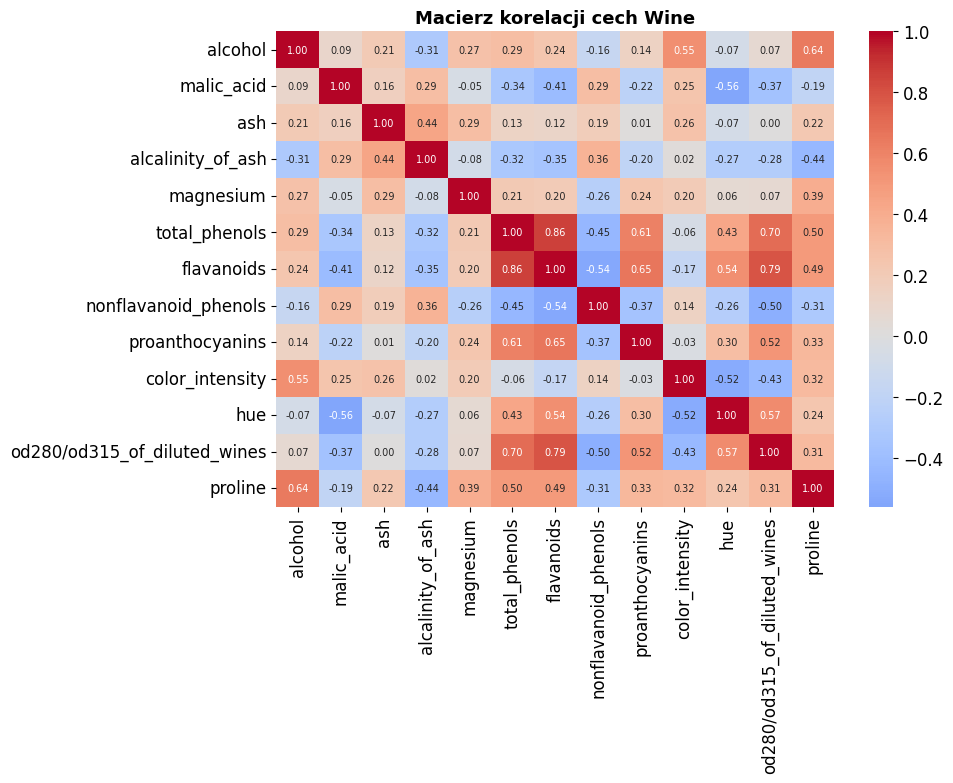

In [8]:
# Macierz korelacji
df = pd.DataFrame(X, columns=nazwy_cech)
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Macierz korelacji cech Wine', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()